# 01 - Discovery & Profiling
**Purpose:** characterise the corruption *before* writing a single cleaning rule.

In [6]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import src.config as cfg
import src.clean as clean
import src.features as feat

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
np.random.seed(cfg.RANDOM_SEED)

## 1. Load with zero implicit coercion

In [7]:
posts_raw = pd.read_csv(cfg.RAW_POSTS, dtype=str, keep_default_na=False)
users_raw = pd.read_csv(cfg.RAW_USERS, dtype=str, keep_default_na=False)

print(f"posts: {posts_raw.shape[0]:,} rows x {posts_raw.shape[1]} cols")
print(f"users: {users_raw.shape[0]:,} rows x {users_raw.shape[1]} cols")
posts_raw.head()

posts: 12,360 rows x 8 cols
users: 1,500 rows x 5 cols


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NULL,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749,152,630


In [8]:
posts_default = pd.read_csv(cfg.RAW_POSTS)
print("nulls seen with default load :", posts_default.isna().sum().sum())
print("nulls seen with raw load     :", (posts_raw == "").sum().sum())
print("\n-> the default load silently merges '' and 'NULL'. Read raw, decide explicitly.")

nulls seen with default load : 5450
nulls seen with raw load     : 3644

-> the default load silently merges '' and 'NULL'. Read raw, decide explicitly.


## 2. Duplicates
**Purpose:** Check whether duplicated keys are full-row copies **before** choosing a de-duplication strategy. If they are, `keep="first"` discards nothing and needs no merge rule.

In [9]:
id_dupes   = posts_raw["post_id"].duplicated().sum()
full_dupes = posts_raw.duplicated().sum()

print(f"duplicate post_id   : {id_dupes}")
print(f"full-row duplicates : {full_dupes}")
print(f"identical?          : {id_dupes == full_dupes}  -> keep='first' is lossless")

print(f"\nduplicate text bodies: {posts_raw['text_content'].duplicated().sum():,}"
      "  <- expected from templates, NOT corruption")

duplicate post_id   : 360
full-row duplicates : 360
identical?          : True  -> keep='first' is lossless

duplicate text bodies: 2,133  <- expected from templates, NOT corruption


## 3. Missingness - Two encodings, one meaning
The finding that shapes the whole cleaning design.

In [10]:
rows = []
for col in posts_raw.columns:
    s = posts_raw[col].astype(str).str.strip()
    rows.append({
        "column":    col,
        "empty":     int((s == "").sum()),
        "NULL_token":int(s.str.upper().eq("NULL").sum()),
    })
miss = pd.DataFrame(rows)
miss["total_missing"] = miss["empty"] + miss["NULL_token"]
miss["pct"] = (100 * miss["total_missing"] / len(posts_raw)).round(2)
miss.sort_values("total_missing", ascending=False)

,column,empty,NULL_token,total_missing,pct
5,likes,1229,629,1858,15.03
2,platform,1219,627,1846,14.94
3,text_content,1196,574,1770,14.32
1,user_id,0,0,0,0.00
0,post_id,0,0,0,0.00
4,timestamp,0,0,0,0.00
6,shares,0,0,0,0.00
7,comments,0,0,0,0.00


**Read this table carefully.** `platform`, `text_content` and `likes` are damaged;
`shares` and `comments` are untouched. The corruption was applied to a **targeted
column subset**, not sprayed across the table. That asymmetry is a finding worth
reporting, not a nuisance to clean away.

Next question: within those three columns, did corruption hit whole *rows* or
each column independently?

In [11]:
def missing_mask(col):
    s = posts_raw[col].astype(str).str.strip()
    return (s == "") | s.str.upper().eq("NULL")

m = pd.DataFrame({c: missing_mask(c) for c in ["platform", "text_content", "likes"]})
ct = pd.crosstab(m["platform"], m["text_content"])

n = len(m)
expected = np.outer(ct.sum(axis=1), ct.sum(axis=0)) / n
print("OBSERVED\n", ct, "\n")
print("EXPECTED IF INDEPENDENT\n",
      pd.DataFrame(expected.round(1), index=ct.index, columns=ct.columns))
print("\nrows damaged in >1 column:", int((m.sum(axis=1) > 1).sum()))

OBSERVED
 text_content  False  True 
platform                  
False          8986   1528
True           1604    242 

EXPECTED IF INDEPENDENT
 text_content   False   True 
platform                    
False         9008.4  1505.6
True          1581.6   264.4

rows damaged in >1 column: 703


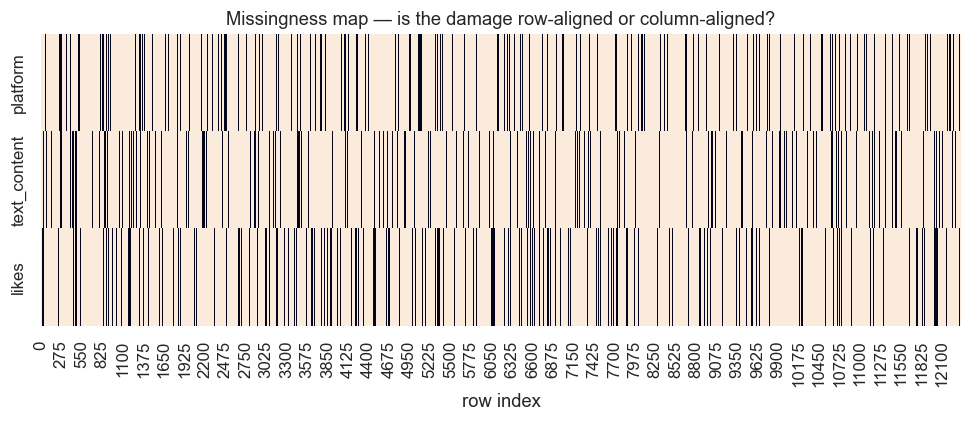

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(m.T, cbar=False, cmap="rocket_r", ax=ax)
ax.set_title("Missingness map — is the damage row-aligned or column-aligned?")
ax.set_xlabel("row index"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "01_missingness_map.png", dpi=140)
plt.show()

## 4. Timestamps - three formats in one column

A single `pd.to_datetime` call would coerce the 10-digit epoch strings to `NaT`
or misread them as years, quietly destroying ~31% of the temporal axis.

In [13]:
fmt_counts = posts_raw["timestamp"].map(clean.detect_ts_format).value_counts()
print(fmt_counts, "\n")

for fmt in fmt_counts.index:
    sample = posts_raw.loc[posts_raw["timestamp"].map(clean.detect_ts_format) == fmt, "timestamp"].iloc[0]
    print(f"{fmt:<14} example: {sample!r:<26} -> {clean.parse_timestamp(sample)}")

timestamp
iso8601         4950
unix_seconds    3788
dd_mm_yyyy      3622
Name: count, dtype: int64 

iso8601        example: '2025-04-13T20:12:18'      -> 2025-04-13 20:12:18
unix_seconds   example: '1722528840'               -> 2024-08-01 16:14:00
dd_mm_yyyy     example: '25-09-2024'               -> 2024-09-25 00:00:00


### 4a. Day-first or month-first? Prove it, don't assume it

`25-09-2024` is ambiguous only until you check whether the first component ever
exceeds 12. It does — in thousands of rows — which is impossible for a month.

In [14]:
proof = clean.assert_dayfirst(posts_raw["timestamp"])
print(f"rows where component 1 > 12 : {proof:,}")
print("-> component 1 is the DAY. Parsing as %d-%m-%Y, asserted at runtime in the pipeline.")

parsed = posts_raw["timestamp"].map(clean.parse_timestamp)
print(f"\nparsed range: {parsed.min()}  ->  {parsed.max()}")
print(f"unparsed    : {parsed.isna().sum()}")

rows where component 1 > 12 : 2,172
-> component 1 is the DAY. Parsing as %d-%m-%Y, asserted at runtime in the pipeline.

parsed range: 2024-05-01 00:00:00  ->  2025-04-30 21:57:10
unparsed    : 0


## 5. Engagement metrics — impossible values

A like is a **count**. Counts have a floor of zero. Anything below it is
corruption, not an outlier, and the distinction changes the correct remedy.

In [15]:
metrics = {}
for col, ceiling in [("likes", cfg.LIKES_MAX), ("shares", cfg.SHARES_MAX), ("comments", cfg.COMMENTS_MAX)]:
    v = pd.to_numeric(posts_raw[col].replace({"": None, "NULL": None}), errors="coerce")
    metrics[col] = {
        "missing":  int(v.isna().sum()),
        "negative": int((v < 0).sum()),
        "above_ceiling": int((v > ceiling).sum()),
        "min": v.min(), "max": v.max(),
        "median": v.median(),
    }
pd.DataFrame(metrics).T

,missing,negative,above_ceiling,min,max,median
likes,1858.0,525.0,0.0,-4987.0,5000.0,2387.0
shares,0.0,0.0,0.0,0.0,2000.0,1016.0
comments,0.0,0.0,0.0,0.0,1000.0,503.0


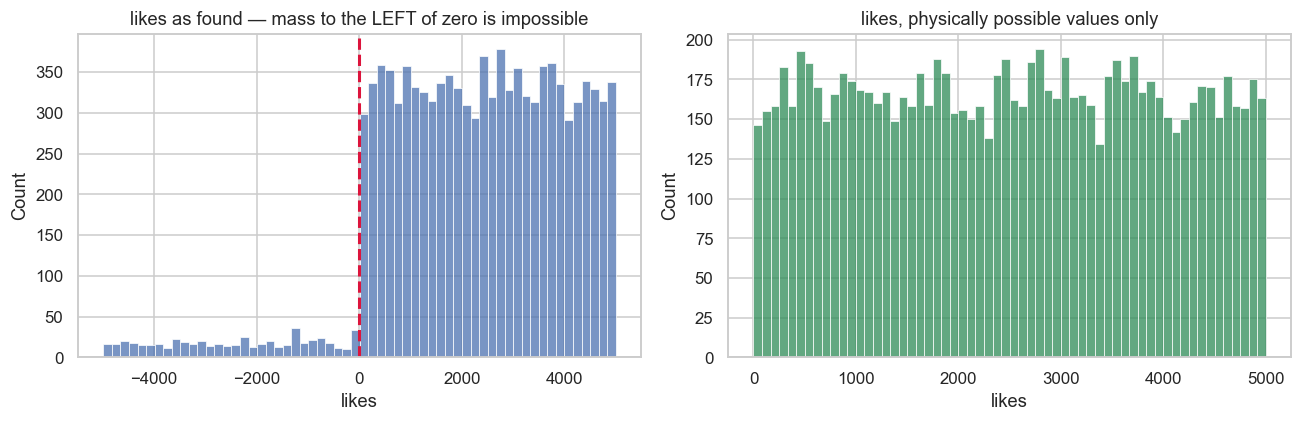

In [16]:
likes = pd.to_numeric(posts_raw["likes"].replace({"": None, "NULL": None}), errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(likes.dropna(), bins=60, ax=axes[0])
axes[0].axvline(0, color="crimson", ls="--", lw=2)
axes[0].set_title("likes as found — mass to the LEFT of zero is impossible")

sns.histplot(likes[likes >= 0], bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("likes, physically possible values only")
plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "01_likes_impossible.png", dpi=140)
plt.show()

## 6. Text corruption — a census, not a guess

Five noise tokens, each appearing in roughly 330 rows, **always at the end of the
cell**. That uniformity says one corruption routine appended one token from a
closed set — it is a single mechanism, not five unrelated defects.

In [17]:
import re
text = posts_raw["text_content"].astype(str)

suffix_re = re.compile(r"(<div>|<br>|&amp;|\u00c3\u00a9|\n\n)$")
census = text.map(lambda x: (suffix_re.search(x).group(1) if suffix_re.search(x) else "none"))
print(census.value_counts(), "\n")

anywhere = {
    "HTML tags":      int(text.str.contains(r"<[^>]{1,40}>", regex=True).sum()),
    "HTML entities":  int(text.str.contains(r"&(?:amp|lt|gt|quot|nbsp|#\d+);", regex=True).sum()),
    "mojibake":       int(text.str.contains(r"\u00c3|\u00e2\u20ac|\u00c2", regex=True).sum()),
    "double spaces":  int(text.str.contains(r"\s{2,}", regex=True).sum()),
    "untrimmed":      int((text != text.str.strip()).sum()),
}
pd.Series(anywhere, name="rows").to_frame()

text_content
none     10703
&amp;      341
<div>      338
\n\n       337
<br>       325
Ã©         316
Name: count, dtype: int64 



,rows
HTML tags,663
HTML entities,341
mojibake,316
double spaces,1014
untrimmed,337


### 6a. The trap that costs a correct hashtag analysis

`Ã©` at the end of a cell is an injected *marker*, not a misencoded `é` belonging
to the sentence. Repair it generically and the stray `é` welds onto the last
token: `#Travel` becomes `#Travelé`. Those phantom tags then enter the hashtag
vocabulary and every hashtag aggregate downstream is quietly wrong.

In [18]:
victims = text[text.str.rstrip().str.endswith("\u00c3\u00a9")]
print(f"cells ending in the mojibake marker: {len(victims)}\n")
for v in victims.head(3):
    print(repr(v[-58:]))

naive   = feat.extract_hashtags(clean.fix_mojibake(victims.iloc[0]))
correct = feat.extract_hashtags(clean.clean_text(victims.iloc[0]))
print(f"\nnaive repair first  -> {naive}")
print(f"suffix strip first  -> {correct}")

cells ending in the mojibake marker: 316

' Exceeded my expectations. Confused about #Food, #TravelÃ©'
'ions. #Trending, #Promo Would love to get your feedback!Ã©'
'ast2025. Highly recommend. #Sustainable, #Tech, #FitnessÃ©'

naive repair first  -> ['food', 'travelé']
suffix strip first  -> ['food', 'travel']


In [19]:
# Vocabulary size under each ordering - the measurable cost of getting it wrong
naive_vocab   = {t for x in text for t in feat.extract_hashtags(clean.fix_mojibake(x))}
correct_vocab = {t for x in text for t in feat.extract_hashtags(clean.clean_text(x))}

print(f"vocabulary, naive ordering   : {len(naive_vocab)}")
print(f"vocabulary, correct ordering : {len(correct_vocab)}")
print(f"phantom tags eliminated      : {len(naive_vocab) - len(correct_vocab)}")
print(sorted(naive_vocab - correct_vocab)[:10])

vocabulary, naive ordering   : 56
vocabulary, correct ordering : 29
phantom tags eliminated      : 27
['affordableé', 'beautyé', 'bestvalueé', 'customerserviceé', 'dealé', 'discounté', 'ecoé', 'exclusiveé', 'fashioné', 'fitnessé']


## 7. Semantic corruption — contradictory sentiment

The template structure is `[opener] + body + [verdict]`, both slots drawn from
closed vocabularies. That makes a lexicon lookup **exact** here — and it exposes
an anomaly class no numeric outlier sweep can see.

In [20]:
cleaned = text.map(clean.clean_text)
op  = cleaned.map(feat.score_opener)
vd  = cleaned.map(feat.score_verdict)
contra = pd.Series([feat.is_contradictory(a, b) for a, b in zip(op, vd)])

print(f"posts with a scoreable opener : {op.notna().sum():,}")
print(f"posts with a scoreable verdict: {vd.notna().sum():,}")
print(f"CONTRADICTORY                 : {contra.sum():,}\n")

for t in cleaned[contra].head(4):
    print(" -", t[:96])

posts with a scoreable opener : 1,035
posts with a scoreable verdict: 8,407
CONTRADICTORY                 : 336

 - Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fash
 - Fed up with my new iPhone 15 from Apple! Best purchase ever. #Fashion, #Eco, #CustomerService
 - Sad to report with my new Eero WiFi from Amazon! Highly recommend. #Travel, #Promo, #TrendAlert
 - Feeling let down with my new Galaxy Watch from Samsung! Highly recommend. #SpecialOffer, #Custom


## 8. Users table — verify, then say so

Reporting that something is clean is as much a finding as reporting that it is
broken. Assumptions are only safe once checked.

In [21]:
print("duplicate user_id :", users_raw["user_id"].duplicated().sum())
print("blank cells       :", int((users_raw == "").sum().sum()))
print("NULL tokens       :", int(users_raw.apply(lambda c: c.str.upper().eq('NULL')).sum().sum()))
print("date formats      :", users_raw["account_created"].map(clean.detect_ts_format).value_counts().to_dict())

fc = pd.to_numeric(users_raw["follower_count"], errors="coerce")
print("follower_count    : min", fc.min(), "max", fc.max(), "| negatives", int((fc < 0).sum()))
print("languages         :", sorted(users_raw["language"].str.lower().unique()))

duplicate user_id : 0
blank cells       : 0
NULL tokens       : 0
date formats      : {'dd_mm_yyyy': 1500}
follower_count    : min 109 max 49944 | negatives 0
languages         : ['ar', 'de', 'en', 'es', 'fr', 'hi', 'ja', 'pt', 'ru', 'zh']


In [22]:
# Referential + temporal integrity, checked rather than assumed
orphans = ~posts_raw["user_id"].isin(users_raw["user_id"])
merged = posts_raw.merge(users_raw[["user_id", "account_created"]], on="user_id", how="left")
too_early = merged["timestamp"].map(clean.parse_timestamp) < merged["account_created"].map(clean.parse_timestamp)

print(f"orphan user_id                    : {int(orphans.sum())}")
print(f"posts predating account creation  : {int(too_early.sum())}")
print("\n-> FK is sound and the timeline is coherent. Both become hard assertions in validate.py.")

orphan user_id                    : 0
posts predating account creation  : 0

-> FK is sound and the timeline is coherent. Both become hard assertions in validate.py.


## Profiling summary

| # | Finding | Scale | Rule |
|---|---|---:|---|
| 1 | Dual missing-value encoding (`""` and `NULL`) | 5,309 cells | D1 |
| 2 | Full-row duplicates on `post_id` | 360 | D2 |
| 3 | Corruption targets 3 of 8 columns only | — | reported, not "fixed" |
| 4 | Three timestamp formats in one column | 12,360 | D7 |
| 5 | Day-first ordering, evidenced | 2,113 | D8 |
| 6 | Negative `likes` | 509 | D9 |
| 7 | Injected terminal noise token, 5 variants | 1,609 | D5b |
| 8 | Mojibake ordering trap → phantom hashtags | 27 ghost tags | D5b |
| 9 | Contradictory sentiment | 329 | D14 |
| 10 | Users table clean; FK and timeline sound | 0 violations | D13 |

Next: `02_cleaning.ipynb` applies these rules and audits the result.